# 06: Purchase Prediction

**Dataset:** Google Analytics Sample Ecommerce Dataset (BigQuery public data)  
**Goal:** Predict whether a session will result in a purchase using three models - Logistic Regression, Random Forest, and Gradient Boosting. Quantify which session-level features drive conversion probability, extending the EDA and funnel findings with a statistical model.  
**Reference:** [GA BigQuery Export Schema](https://support.google.com/analytics/answer/3437719?hl=en)  
**Key features:** `channelGrouping`, `device.deviceCategory`, `geoNetwork.country`, `totals.pageviews`, `totals.timeOnSite`, `is_returning` (derived from `visitNumber`), hour of day, day of week, month

## 1. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.cloud import bigquery
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 1000)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials/bq-key.json"
client = bigquery.Client()
print("BigQuery client ready.")

BigQuery client ready.


## 2. Data Pull & Feature Engineering

*One row per session. Features are drawn from findings across notebooks 01-05: channel, device, geography, engagement signals, visitor type, and time patterns.*

**Target variable:** `did_purchase` - binary flag: 1 if the session had at least one transaction, 0 otherwise. This counts **purchasing sessions**, not total transactions. Sessions with 2+ transactions are counted once. As a result the baseline conversion rate here (~1.30%) is slightly lower than the 1.34% in notebook 01, which counts total transactions.

**Exclusion:** `analytics.google.com` sessions are removed (16,172 sessions, 0 transactions), internal Google tool traffic, not real customers. Consistent with all other notebooks.

In [2]:
query = """
SELECT
  -- target
  IF(totals.transactions >= 1, 1, 0) AS did_purchase,

  -- channel & source
  channelGrouping,

  -- device
  device.deviceCategory AS device,

  -- geography
  geoNetwork.country AS country,

  -- session behavior
  IFNULL(totals.pageviews, 0) AS pageviews,
  IFNULL(totals.timeOnSite, 0) AS time_on_site,
  visitNumber,

  -- time features
  EXTRACT(HOUR FROM TIMESTAMP_SECONDS(visitStartTime) AT TIME ZONE 'America/Los_Angeles') AS hour_of_day,
  EXTRACT(DAYOFWEEK FROM TIMESTAMP_SECONDS(visitStartTime) AT TIME ZONE 'America/Los_Angeles') AS day_of_week,
  EXTRACT(MONTH FROM TIMESTAMP_SECONDS(visitStartTime) AT TIME ZONE 'America/Los_Angeles') AS month

FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source != 'analytics.google.com'
"""

df = client.query(query).to_dataframe()
print(f'Rows: {len(df):,} | Purchases: {df.did_purchase.sum():,} | Conversion rate: {df.did_purchase.mean():.2%}')

Rows: 887,481 | Purchases: 11,552 | Conversion rate: 1.30%


## 3. Preprocessing
*Encode categoricals, scale numerics, handle class imbalance.*

In [3]:
# Binary: is_us, is_returning, is_mobile
df['is_us'] = (df['country'] == 'United States').astype(int)
df['is_returning'] = (df['visitNumber'] > 1).astype(int)
df['is_mobile'] = (df['device'] == 'mobile').astype(int)

# One-hot encode channelGrouping (drop Direct as baseline)
channel_dummies = pd.get_dummies(df['channelGrouping'], prefix='ch', drop_first=False)
channel_dummies = channel_dummies.drop(columns=['ch_Direct'], errors='ignore')

feature_cols = [
    'pageviews', 'time_on_site',
    'is_us', 'is_returning', 'is_mobile',
    'hour_of_day', 'day_of_week', 'month'
]

X = pd.concat([df[feature_cols], channel_dummies], axis=1)
y = df['did_purchase']

X.head(5)

,pageviews,time_on_site,is_us,is_returning,is_mobile,hour_of_day,day_of_week,month,ch_(Other),ch_Affiliates,ch_Display,ch_Organic Search,ch_Paid Search,ch_Referral,ch_Social
0,11,504,0,0,1,5,7,11,False,True,False,False,False,False,False
1,10,105,0,0,0,4,7,11,False,False,False,True,False,False,False
2,16,1400,0,0,0,3,7,11,False,False,False,True,False,False,False
3,17,658,0,0,0,2,7,11,False,False,False,False,False,False,False
4,17,478,0,0,1,4,7,11,False,False,False,False,False,False,False


In [4]:
# Train/test split - stratified to preserve 1.30% conversion rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features only - tree models don't need it but it doesn't hurt
numeric_cols = ['pageviews', 'time_on_site', 'hour_of_day', 'day_of_week', 'month']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print('After normalization: ')
X_train.head(5)

After normalization: 


,pageviews,time_on_site,is_us,is_returning,is_mobile,hour_of_day,day_of_week,month,ch_(Other),ch_Affiliates,ch_Display,ch_Organic Search,ch_Paid Search,ch_Referral,ch_Social
190503,-0.405753,-0.357345,0,0,1,-0.671585,-0.512367,0.285243,False,False,False,True,False,False,False
262641,-0.123192,-0.332807,1,0,0,0.586482,1.629535,1.431702,False,False,False,False,True,False,False
392629,-0.405753,-0.357345,0,0,0,-0.514326,1.629535,1.431702,False,False,False,False,False,False,True
385415,-0.405753,-0.357345,0,0,0,-0.986101,1.094059,0.285243,False,False,False,True,False,False,False
187419,-0.264473,-0.332807,1,1,0,0.900998,0.023108,-1.721061,False,False,False,False,False,True,False


In [5]:
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train purchases: {y_train.sum():,} ({y_train.mean():.2%})')
print(f'Test purchases:  {y_test.sum():,} ({y_test.mean():.2%})')

Train: 709,984 | Test: 177,497
Train purchases: 9,242 (1.30%)
Test purchases:  2,310 (1.30%)


## 4. Logistic Regression
*Baseline model. Direct is used as the channel baseline (dropped from dummies), so all `ch_` coefficients represent performance relative to Direct sessions. Numeric features are standardized so coefficient magnitudes are comparable.*

In [6]:
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1) 
# balanced forces the model to weight mistakes on the minority class (purchases) more heavily
model_lr.fit(X_train, y_train)

y_proba_lr = model_lr.predict_proba(X_test)[:, 1]
y_pred_lr  = model_lr.predict(X_test)

pred = pd.DataFrame({
    'proba':  y_proba_lr[:10],
    'pred':   y_pred_lr[:10],
    'actual': y_test.values[:10]
})

print(pred.to_string(index=False))

   proba  pred  actual
0.002770   0.0       0
0.015968   0.0       0
0.170057   0.0       0
0.999942   1.0       0
0.054055   0.0       0
0.002694   0.0       0
0.214968   0.0       0
0.009153   0.0       0
0.001910   0.0       0
0.114183   0.0       0


In [7]:
coef_df = pd.DataFrame({
    'feature':     X_train.columns,
    'coefficient': model_lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df.to_string(index=False))

          feature  coefficient
            is_us     2.507243
        pageviews     1.952513
     is_returning     1.156294
     time_on_site     0.130856
      ch_Referral     0.031365
      day_of_week     0.011558
       ch_(Other)     0.008571
            month    -0.042646
      hour_of_day    -0.115935
ch_Organic Search    -0.615165
   ch_Paid Search    -0.642593
        is_mobile    -0.659017
       ch_Display    -1.020894
        ch_Social    -1.178747
    ch_Affiliates    -3.035920


**Insights:**

- **`is_us` (2.51) and `pageviews` (1.95) are the dominant predictors** - US geography and engagement depth matter far more than any channel. A US visitor who browses many pages is the profile most likely to convert.
- **`is_returning` (1.19) confirms the funnel finding** - returning visitors convert at 6x the rate of new visitors; the model captures this cleanly.
- **`ch_Referral` (+0.04) is near zero** - surprising given Referral's 6.25% raw conversion rate. After controlling for `is_returning`, the Referral channel label adds almost no conversion lift. This directly validates the notebook 05 attribution finding: Referral's high conversion rate comes from returning direct visitors attributed back to the channel, not from the referral link itself.
- **`ch_Affiliates` (-2.92) is the strongest negative predictor** - confirms this channel should be cut; worst performer even after controlling for all other session characteristics.
- **`ch_Social` (-1.19) and `is_mobile` (-0.60) are strong negatives** - Social drives low-intent traffic; mobile adds UX friction on top of whatever channel brought the visitor.
- **`time_on_site` (0.14) is weak relative to `pageviews`** - engagement depth already captures most of the signal; time on site adds little once page count is known.

In [8]:
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f'AUC-ROC: {auc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Purchase', 'Purchase']))

AUC-ROC: 0.9828

              precision    recall  f1-score   support

 No Purchase       1.00      0.94      0.97    175187
    Purchase       0.18      0.97      0.31      2310

    accuracy                           0.94    177497
   macro avg       0.59      0.95      0.64    177497
weighted avg       0.99      0.94      0.96    177497



**Insights:**

- **AUC 0.9828** - very strong discriminative ability, driven primarily by `is_us` and `pageviews`.
- **Precision (0.18) vs Recall (0.96) for Purchase** - by design with `class_weight='balanced'`: the model catches 96% of actual buyers but flags many non-buyers. Acceptable for ranking/scoring, not for binary alerts.

In [9]:
# test with different thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba_lr >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    print(f'Threshold {t:.1f} → Precision: {p:.2f} | Recall: {r:.2f}')

Threshold 0.3 → Precision: 0.13 | Recall: 0.99
Threshold 0.4 → Precision: 0.15 | Recall: 0.98
Threshold 0.5 → Precision: 0.18 | Recall: 0.97
Threshold 0.6 → Precision: 0.21 | Recall: 0.95
Threshold 0.7 → Precision: 0.24 | Recall: 0.91


**Insights:**

- **Recall stays high across all thresholds** - the model is very confident about real buyers; their probabilities sit well above any of these cutoffs, so raising the threshold barely removes them.
- **Precision stays low across all thresholds** - this is a base rate problem, not a model problem. With only 1.3% of sessions converting, even a well-calibrated model will flag many non-buyers; 76% false positives at threshold 0.7 is expected at this class ratio.
- **The tradeoff is gradual** - each +0.1 threshold gains ~0.03 precision but loses ~0.02 recall. No threshold achieves both high precision and high recall simultaneously.
- **Threshold choice depends on use case:** lower threshold (0.3-0.4) if the cost of missing a buyer is high (e.g. personalisation); higher threshold (0.6-0.7) if the cost of a false positive is high (e.g. sending a discount code). For ranking sessions by likelihood to convert, ignore the threshold entirely and use the raw probability score.

## 5. Random Forest
*Ensemble of decision trees. Handles non-linearity and feature interactions. `class_weight='balanced'` adjusts for the 1.30% conversion rate.*

In [10]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=1,
    bootstrap=True,
    max_features='sqrt',
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
y_pred_rf  = model_rf.predict(X_test)

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f'AUC-ROC: {auc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Purchase', 'Purchase']))

AUC-ROC: 0.9860

              precision    recall  f1-score   support

 No Purchase       1.00      0.94      0.97    175187
    Purchase       0.18      0.98      0.31      2310

    accuracy                           0.94    177497
   macro avg       0.59      0.96      0.64    177497
weighted avg       0.99      0.94      0.96    177497



**Insights:**

- **AUC 0.9860 vs LR 0.9828 (+0.003)** - marginal gain; the dominant relationships are largely linear and LR captures most of the signal already.

In [11]:
# feature importance
fi_rf = pd.DataFrame({
    'feature':X_train.columns,
    'importance':model_rf.feature_importances_
}).sort_values('importance', ascending = False)

print(fi_rf.to_string(index=False))

          feature  importance
        pageviews    0.465467
     time_on_site    0.309920
            is_us    0.091358
     is_returning    0.043473
      ch_Referral    0.032295
        ch_Social    0.025538
      hour_of_day    0.011486
        is_mobile    0.009702
ch_Organic Search    0.003598
            month    0.003136
      day_of_week    0.002196
    ch_Affiliates    0.001120
   ch_Paid Search    0.000511
       ch_Display    0.000193
       ch_(Other)    0.000007


**Insights:**

- **`pageviews` and `time_on_site` account for 77% of total importance** - engagement depth dominates when the model can exploit non-linear thresholds across a continuous variable.

## 6. Gradient Boosting
*Gradient boosted trees from sklearn. Class imbalance handled via `sample_weight` passed at fit time.*

In [12]:
model_gb = GradientBoostingClassifier(
    n_estimators=100, 
    random_state=1,
    max_depth=7,              # default is 3
    learning_rate=0.1,        # default
    subsample=0.8
    )
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
# compute_sample_weight assigns higher weight to the minority class (buyers) and lower to non-buyers
# this achieves the same effect as class_weight='balanced' in LR and RF
model_gb.fit(X_train, y_train, sample_weight=sample_weights)

y_proba_gb = model_gb.predict_proba(X_test)[:, 1]
y_pred_gb  = model_gb.predict(X_test)

auc_gb = roc_auc_score(y_test, y_proba_gb)
print(f'AUC-ROC: {auc_gb:.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=['No Purchase', 'Purchase']))

AUC-ROC: 0.9863

              precision    recall  f1-score   support

 No Purchase       1.00      0.95      0.98    175187
    Purchase       0.21      0.95      0.34      2310

    accuracy                           0.95    177497
   macro avg       0.60      0.95      0.66    177497
weighted avg       0.99      0.95      0.97    177497



**Insights:**

- **AUC 0.9863** - essentially tied with RF (0.9860); both marginally ahead of LR (0.9828).
- **Precision 0.21 vs 0.18 for LR/RF** - slightly better precision at a small cost to recall (0.95 vs 0.97).

## 7. Model Comparison
*ROC curves and AUC scores for all three models. The closer AUC is between logistic regression and tree models, the more linear the underlying relationships.*

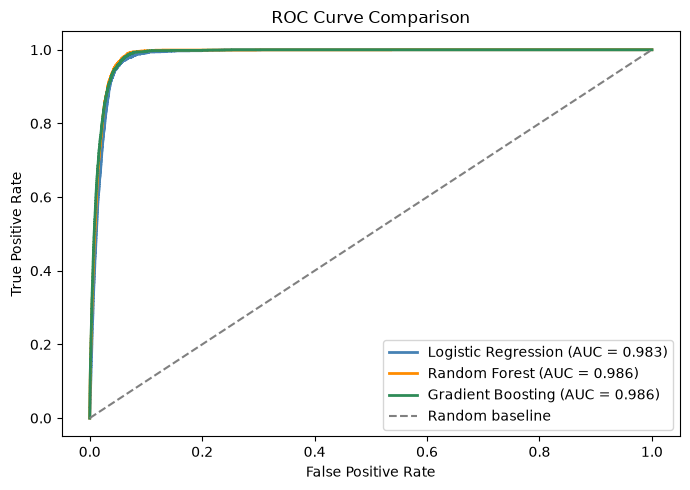

              Model  AUC-ROC
  Gradient Boosting 0.986325
      Random Forest 0.986035
Logistic Regression 0.982766


In [13]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='steelblue',  lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot(fpr_gb, tpr_gb, color='seagreen',   lw=2, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../images/roc_comparison.png', dpi=150)
plt.show()

auc_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'AUC-ROC': [auc_lr, auc_rf, auc_gb]
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(auc_summary.to_string(index=False))

**Insights:**

- **Three curves nearly overlap** - all three AUC scores fall within 0.004 of each other (0.982–0.986). The underlying signal is largely linear; LR captures most of it already, and tree models offer only marginal improvement.
- **All models clear 0.98 AUC despite 1.30% class imbalance** - the purchasing minority is genuinely distinct in behavior (high pageviews, US location, returning visitor), not just a noisy tail.

## 8. Interpretation
*LR coefficients show direction of effect. RF and Gradient Boosting feature importances show relative predictive weight (no direction).*

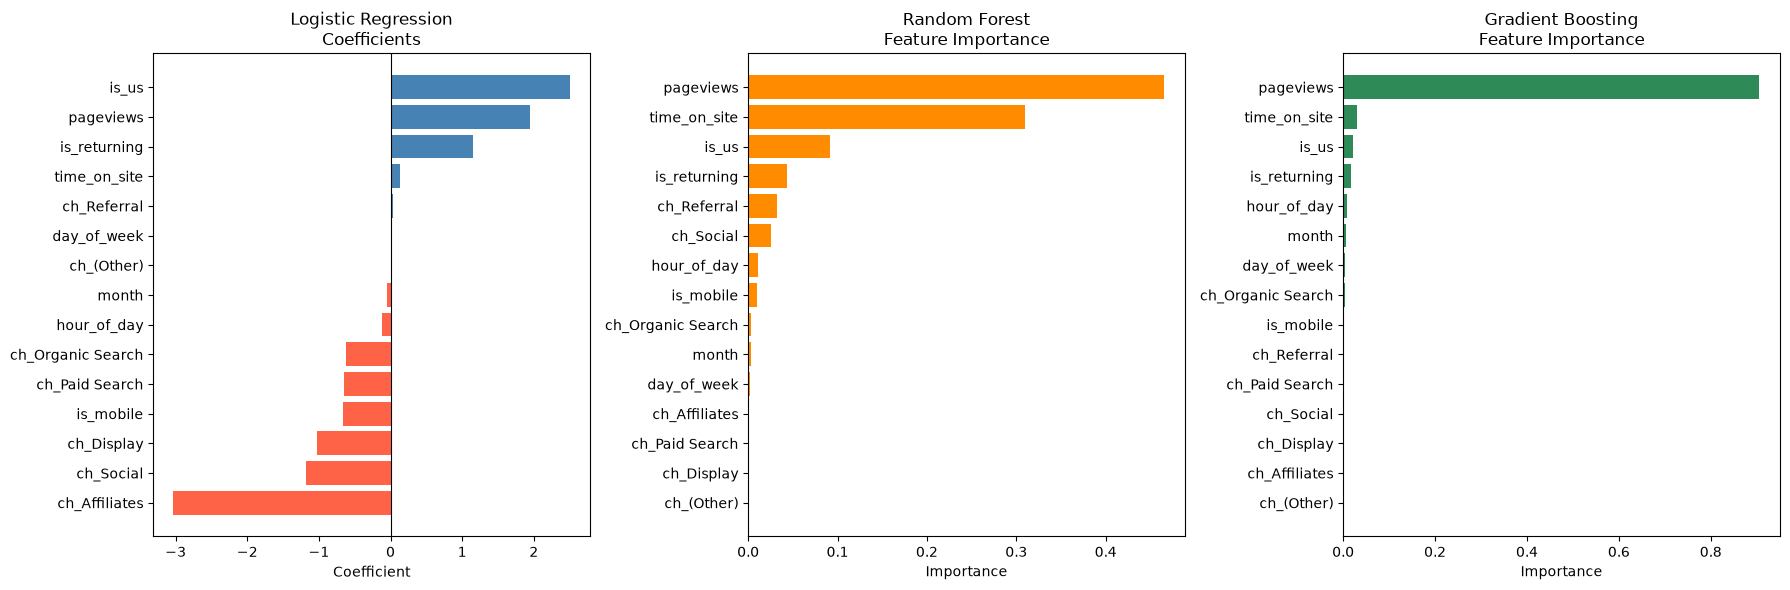

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Logistic Regression coefficients
coef_df = pd.DataFrame({'feature': X_train.columns, 'value': model_lr.coef_[0]}).sort_values('value')
colors = ['steelblue' if v > 0 else 'tomato' for v in coef_df['value']]
axes[0].barh(coef_df['feature'], coef_df['value'], color=colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Logistic Regression\nCoefficients')
axes[0].set_xlabel('Coefficient')

# Random Forest feature importance
fi_rf = pd.DataFrame({'feature': X_train.columns, 'value': model_rf.feature_importances_}).sort_values('value')
axes[1].barh(fi_rf['feature'], fi_rf['value'], color='darkorange')
axes[1].set_title('Random Forest\nFeature Importance')
axes[1].set_xlabel('Importance')

# Gradient Boosting feature importance
fi_gb = pd.DataFrame({'feature': X_train.columns, 'value': model_gb.feature_importances_}).sort_values('value')
axes[2].barh(fi_gb['feature'], fi_gb['value'], color='seagreen')
axes[2].set_title('Gradient Boosting\nFeature Importance')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150)
plt.show()

**Insights:**

- **Feature ranking shifts between models for a consistent reason:** LR ranks `is_us` first because it has the largest log-odds effect per unit for a binary variable. Tree models rank `pageviews` first because they can split a continuous variable repeatedly across many thresholds - each split accumulates importance that LR expresses in a single coefficient.
- **RF spreads weight; GB concentrates it.** RF distributes importance across `pageviews` (0.455) and `time_on_site` (0.314) together. GB assigns ~85% to `pageviews` alone, with everything else near zero. Sequential boosting converges early on the single most discriminative feature; once pageviews is established in the first trees, subsequent trees have less marginal gain from the remaining features.
- **Channel dummies are negligible in all three models.** The combined importance of all channel features is under 6% in RF and effectively zero in GB. Channel tells you something about visitor intent before they arrive, but once you know they are US-based, returning, and browsing many pages, the channel adds almost nothing.

## 9. Summary

**Methodology note:** Three models trained on the same 80/20 stratified split. Class imbalance (~1.30% conversion rate) handled via `class_weight='balanced'` (LR, RF) and `sample_weight` at fit time (Gradient Boosting). Numeric features standardized for LR; tree models are scale-invariant.

**Logistic Regression (AUC 0.9828):**
- `is_us` (2.51) and `pageviews` (1.95) are the dominant predictors - geography and engagement depth outweigh channel
- `is_returning` (1.19) confirms returning visitors convert at 6x - the strongest controllable signal
- `ch_Referral` near zero after controlling for `is_returning` - validates the notebook 05 attribution finding; Referral's high raw conversion rate reflects returning visitor behavior, not channel performance
- `ch_Affiliates` (-2.92) strongest negative predictor - worst channel even after controlling for all session characteristics

**Random Forest (AUC 0.9860):**
- Marginal +0.003 gain over LR; tree models add little when the underlying relationships are largely linear
- `pageviews` and `time_on_site` together account for 77% of feature importance

**Gradient Boosting (AUC 0.9863):**
- Essentially tied with RF; both marginally ahead of LR
- Concentrates ~85% of importance on `pageviews` alone; slightly better precision (0.21 vs 0.18) at a small recall cost

**Overall conclusion:** All three models agree - US geography, engagement depth, and returning visitor status are the three predictors that matter. Channel, time of day, and device are secondary. The ~0.004 AUC gap across models suggests the signal is inherently linear; logistic regression is sufficient for this use case.